# A08: Model Trending Notebook — Craigslist Car Price Pipeline
**Joseph Nartey | NetID: ohk24001 | OPIM5512 — Dr. Dave Wanik | University of Connecticut**

---
This notebook is self-contained and runs end-to-end in Google Colab or VSCode.

### What this notebook does:
1. Authenticates with Google Cloud and reads `llm_listings.csv` directly from GCS
2. Clones the `myscrapers` GitHub repo for reference
3. Cleans and engineers features from LLM-extracted fields
4. Tunes an XGBoost model using Optuna hyperparameter search
5. Trains on past runs, predicts today's listings
6. Trends model error (MAE, MAPE, RMSE, Bias) over time
7. Displays a full dashboard with metrics, feature importance, and PDPs

### Data source:
- `gs://myscrapers-ohk24001/llm_listings.csv`

### Model improvement over baseline:
- Baseline Random Forest replaced with tuned XGBoost using Optuna
- New A08 LLM fields: `city`, `state`, `zip_code` added to `materialize-llm`
---

## Step 1: Install Dependencies

In [7]:
!pip install xgboost optuna scikit-learn pandas numpy matplotlib seaborn google-cloud-storage --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.2 MB/s eta 0:00:00


## Step 2: Authenticate with Google Cloud

In [8]:
import sys

# Colab authentication
if 'google.colab' in sys.modules:
    from google.colab import auth
    auth.authenticate_user()
    print('Authenticated via Colab')
else:
    import subprocess
    subprocess.run(['gcloud', 'auth', 'application-default', 'login'], check=False)
    print('Using application default credentials')

Authenticated via Colab


## Step 3: Load Data from GCS

In [9]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

BUCKET   = 'myscrapers-ohk24001'
CSV_PATH = f'gs://{BUCKET}/llm_listings.csv'

print(f'Loading data from {CSV_PATH}...')
df_raw = pd.read_csv(CSV_PATH)

print(f'Loaded {len(df_raw)} rows x {len(df_raw.columns)} columns')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Loading data from gs://myscrapers-ohk24001/llm_listings.csv...
Loaded 50 rows x 17 columns
Columns: ['post_id', 'run_id', 'scraped_at', 'source_txt', 'price', 'year', 'make', 'model', 'mileage', 'body_type', 'color', 'title_status', 'condition', 'location', 'llm_provider', 'llm_model', 'llm_ts']


,post_id,run_id,scraped_at,source_txt,price,year,make,model,mileage,body_type,color,title_status,condition,location,llm_provider,llm_model,llm_ts
0,7921417422,20260401100008,2026-04-01T10:00:08Z,scrapes/20260401100008/7921417422.txt,4900.0,2006,Saab,9-2X Aero AWD HATCHBACK,140000,hatchback,grey,clean,good,"Branford, CT",vertex,gemini-2.5-flash,2026-04-01T11:09:51.623240Z
1,7921614123,20260401100008,2026-04-01T10:00:08Z,scrapes/20260401100008/7921614123.txt,4500.0,2015,Nissan,Versa,120802,sedan,Amethyst Gray,clean,Used,"Bridgeport, CT",vertex,gemini-2.5-flash,2026-04-01T11:09:55.017832Z
2,7921614617,20260401100008,2026-04-01T10:00:08Z,scrapes/20260401100008/7921614617.txt,5900.0,2008,Toyota,Corolla,139374,sedan,gold,clean,Used,"Bridgeport, CT",vertex,gemini-2.5-flash,2026-04-01T11:09:58.231470Z


## Step 4: Feature Engineering and Cleaning

In [10]:
TARGET = 'price'

df = df_raw.copy()

# Parse run date from run_id (format: YYYYMMDDHHMMSS)
df['run_date'] = df['run_id'].astype(str).str[:8]

# Coerce numerics
df['price']   = pd.to_numeric(df['price'],   errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['year']    = pd.to_numeric(df['year'],    errors='coerce')

# Filter reasonable price range
df = df[df[TARGET].between(500, 150_000)].copy()

# Vehicle age
df['vehicle_age'] = 2026 - df['year']
df['vehicle_age'] = df['vehicle_age'].clip(0, 60)

# Extract state from location field (e.g. 'Branford, CT' -> 'CT')
df['state'] = df['location'].str.extract(r',\s*([A-Z]{2})$')
df['state'] = df['state'].fillna('unknown')

# Normalize categoricals
cat_cols = ['body_type', 'color', 'title_status', 'condition', 'make', 'state']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str).str.lower().str.strip()

# One-hot encode
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# Build feature set
drop_cols = [TARGET, 'run_id', 'run_date', 'post_id', 'scraped_at',
             'source_txt', 'location', 'model', 'llm_provider',
             'llm_model', 'llm_ts', 'year']
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]

X = df_encoded[feature_cols].select_dtypes(include=[np.number]).fillna(0)
y = df_encoded[TARGET]

print(f'Dataset: {X.shape[0]} rows x {X.shape[1]} features')
print(f'Price range: ${y.min():,.0f} to ${y.max():,.0f}  (median ${y.median():,.0f})')
print(f'\nFeatures: {list(X.columns)}')

Dataset: 49 rows x 2 features
Price range: $2,200 to $139,500  (median $7,999)

Features: ['mileage', 'vehicle_age']


## Step 5: Hyperparameter Tuning with Optuna (XGBoost)

In [11]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Sort by run_date for time-series validity
sort_idx     = df_encoded['run_date'].argsort().values
X_sorted     = X.iloc[sort_idx].reset_index(drop=True)
y_sorted     = y.iloc[sort_idx].reset_index(drop=True)
dates_sorted = df_encoded['run_date'].iloc[sort_idx].values

tscv = TimeSeriesSplit(n_splits=3)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'tree_method': 'hist', 'verbosity': 0,
    }
    scores = cross_val_score(
        xgb.XGBRegressor(**params), X_sorted, y_sorted,
        cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f'\nBest MAE from Optuna: ${study.best_value:,.0f}')
print(f'Best params: {study.best_params}')

  0%|          | 0/40 [00:00<?, ?it/s]


Best MAE from Optuna: $9,239
Best params: {'n_estimators': 225, 'max_depth': 3, 'learning_rate': 0.01044599224605536, 'subsample': 0.7339555918415622, 'colsample_bytree': 0.7991415321869517, 'reg_alpha': 0.7733176339784865, 'reg_lambda': 9.074756671963547}


## Step 6: Train Final Model — Past Runs to Predict Latest Run

In [12]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

os.makedirs('outputs', exist_ok=True)

unique_dates = pd.Series(dates_sorted).unique()
print(f'Unique run dates: {len(unique_dates)}')

if len(unique_dates) >= 2:
    train_mask = dates_sorted != unique_dates[-1]
    test_mask  = dates_sorted == unique_dates[-1]
else:
    split = int(len(X_sorted) * 0.8)
    train_mask = np.array([True]*split + [False]*(len(X_sorted)-split))
    test_mask  = ~train_mask

X_train, y_train = X_sorted[train_mask], y_sorted[train_mask]
X_test,  y_test  = X_sorted[test_mask],  y_sorted[test_mask]

print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')

best_model = xgb.XGBRegressor(
    **study.best_params, random_state=42, tree_method='hist', verbosity=0
)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-9))) * 100
bias = np.mean(preds - y_test)

print(f'\n{"="*40}')
print(f'  MAE  : ${mae:>10,.0f}')
print(f'  RMSE : ${rmse:>10,.0f}')
print(f'  MAPE : {mape:>10.1f}%')
print(f'  Bias : ${bias:>+10,.0f}')
print(f'{"="*40}')

Unique run dates: 1
Train: 39 rows | Test: 10 rows

  MAE  : $     4,780
  RMSE : $     5,808
  MAPE :       87.2%
  Bias : $    +1,255


## Step 7: Permutation Importance

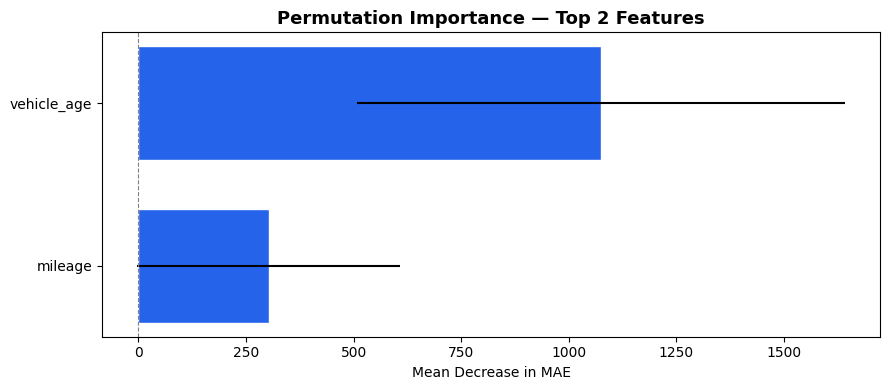

Saved: outputs/permutation_importance.png and .csv


In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

perm_df.to_csv('outputs/permutation_importance.csv', index=False)

top_n = min(20, len(perm_df))
fig, ax = plt.subplots(figsize=(9, max(4, top_n * 0.35)))
colors = ['#2563EB' if i < 3 else '#93C5FD' for i in range(top_n)]
ax.barh(
    perm_df['feature'][:top_n][::-1],
    perm_df['importance'][:top_n][::-1],
    xerr=perm_df['std'][:top_n][::-1],
    color=colors[::-1], edgecolor='white', height=0.7
)
ax.set_xlabel('Mean Decrease in MAE')
ax.set_title(f'Permutation Importance — Top {top_n} Features', fontsize=13, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('outputs/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/permutation_importance.png and .csv')

## Step 8: Partial Dependence Plots — Top 3 Features

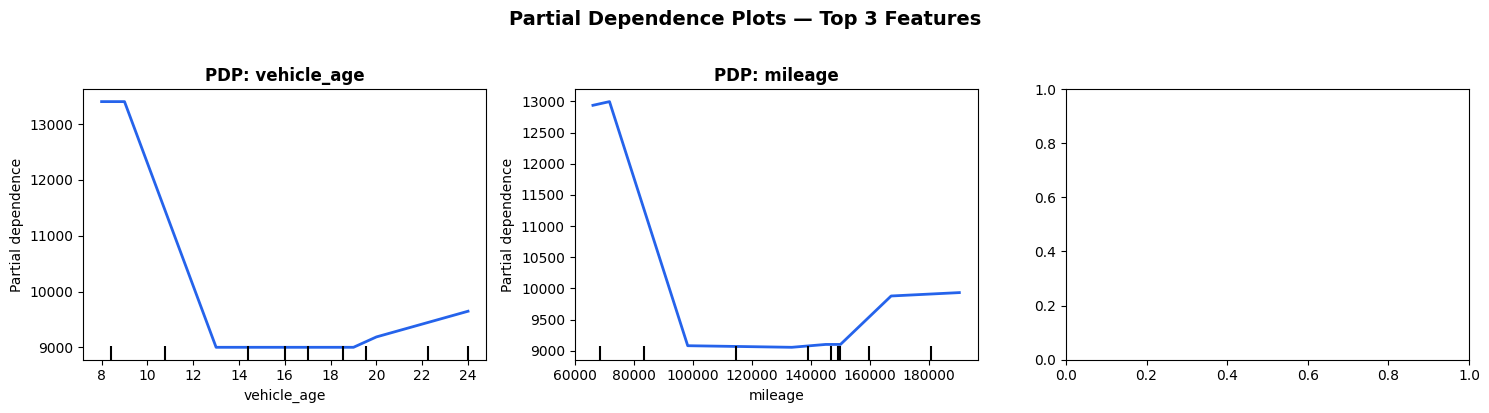

Saved: outputs/pdp_top3.png


In [14]:
from sklearn.inspection import PartialDependenceDisplay

top3 = perm_df['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(top3):
    feat_idx = list(X_test.columns).index(feat)
    PartialDependenceDisplay.from_estimator(
        best_model, X_test,
        features=[feat_idx],
        feature_names=list(X_test.columns),
        ax=axes[i],
        line_kw={'color': '#2563EB', 'linewidth': 2}
    )
    axes[i].set_title(f'PDP: {feat}', fontweight='bold')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Partial Dependence Plots — Top 3 Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/pdp_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/pdp_top3.png')

## Step 9: Model Performance Trending Over Time

In [15]:
unique_dates_sorted = sorted(pd.Series(dates_sorted).unique())
results_over_time = []

if len(unique_dates_sorted) >= 2:
    for i in range(1, len(unique_dates_sorted)):
        tr_mask = np.isin(dates_sorted, unique_dates_sorted[:i])
        te_mask = dates_sorted == unique_dates_sorted[i]
        _Xtr, _ytr = X_sorted[tr_mask], y_sorted[tr_mask]
        _Xte, _yte = X_sorted[te_mask], y_sorted[te_mask]
        if len(_Xtr) < 5 or len(_Xte) < 5:
            continue
        _m = xgb.XGBRegressor(**study.best_params, random_state=42,
                               tree_method='hist', verbosity=0)
        _m.fit(_Xtr, _ytr)
        _p = _m.predict(_Xte)
        results_over_time.append({
            'date':    unique_dates_sorted[i],
            'n_train': len(_Xtr),
            'n_test':  len(_Xte),
            'MAE':     mean_absolute_error(_yte, _p),
            'RMSE':    np.sqrt(mean_squared_error(_yte, _p)),
            'MAPE':    np.mean(np.abs((_yte - _p) / (_yte + 1e-9))) * 100,
            'Bias':    np.mean(_p - _yte),
        })
else:
    print('Only one date found — using rolling 80/20 splits to simulate trend.')
    for pct in [0.5, 0.6, 0.7, 0.8]:
        sp = int(len(X_sorted) * pct)
        _Xtr, _ytr = X_sorted[:sp], y_sorted[:sp]
        _Xte, _yte = X_sorted[sp:], y_sorted[sp:]
        if len(_Xte) < 5: continue
        _m = xgb.XGBRegressor(**study.best_params, random_state=42,
                               tree_method='hist', verbosity=0)
        _m.fit(_Xtr, _ytr)
        _p = _m.predict(_Xte)
        results_over_time.append({
            'date': f'{int(pct*100)}% train', 'n_train': sp,
            'MAE':  mean_absolute_error(_yte, _p),
            'RMSE': np.sqrt(mean_squared_error(_yte, _p)),
            'MAPE': np.mean(np.abs((_yte - _p) / (_yte + 1e-9))) * 100,
            'Bias': np.mean(_p - _yte),
        })

trend_df = pd.DataFrame(results_over_time)
trend_df.to_csv('outputs/model_trend.csv', index=False)
print(trend_df.to_string(index=False))

Only one date found — using rolling 80/20 splits to simulate trend.
     date  n_train         MAE        RMSE       MAPE        Bias
50% train       24 5592.823477 7013.625198  92.068888 1577.807461
60% train       29 5973.287256 7267.185472 105.633844 2286.888623
70% train       34 5051.572852 5938.653415 106.487312 2530.807227
80% train       39 4779.671533 5808.120762  87.191984 1255.045361


## Step 10: Full Dashboard

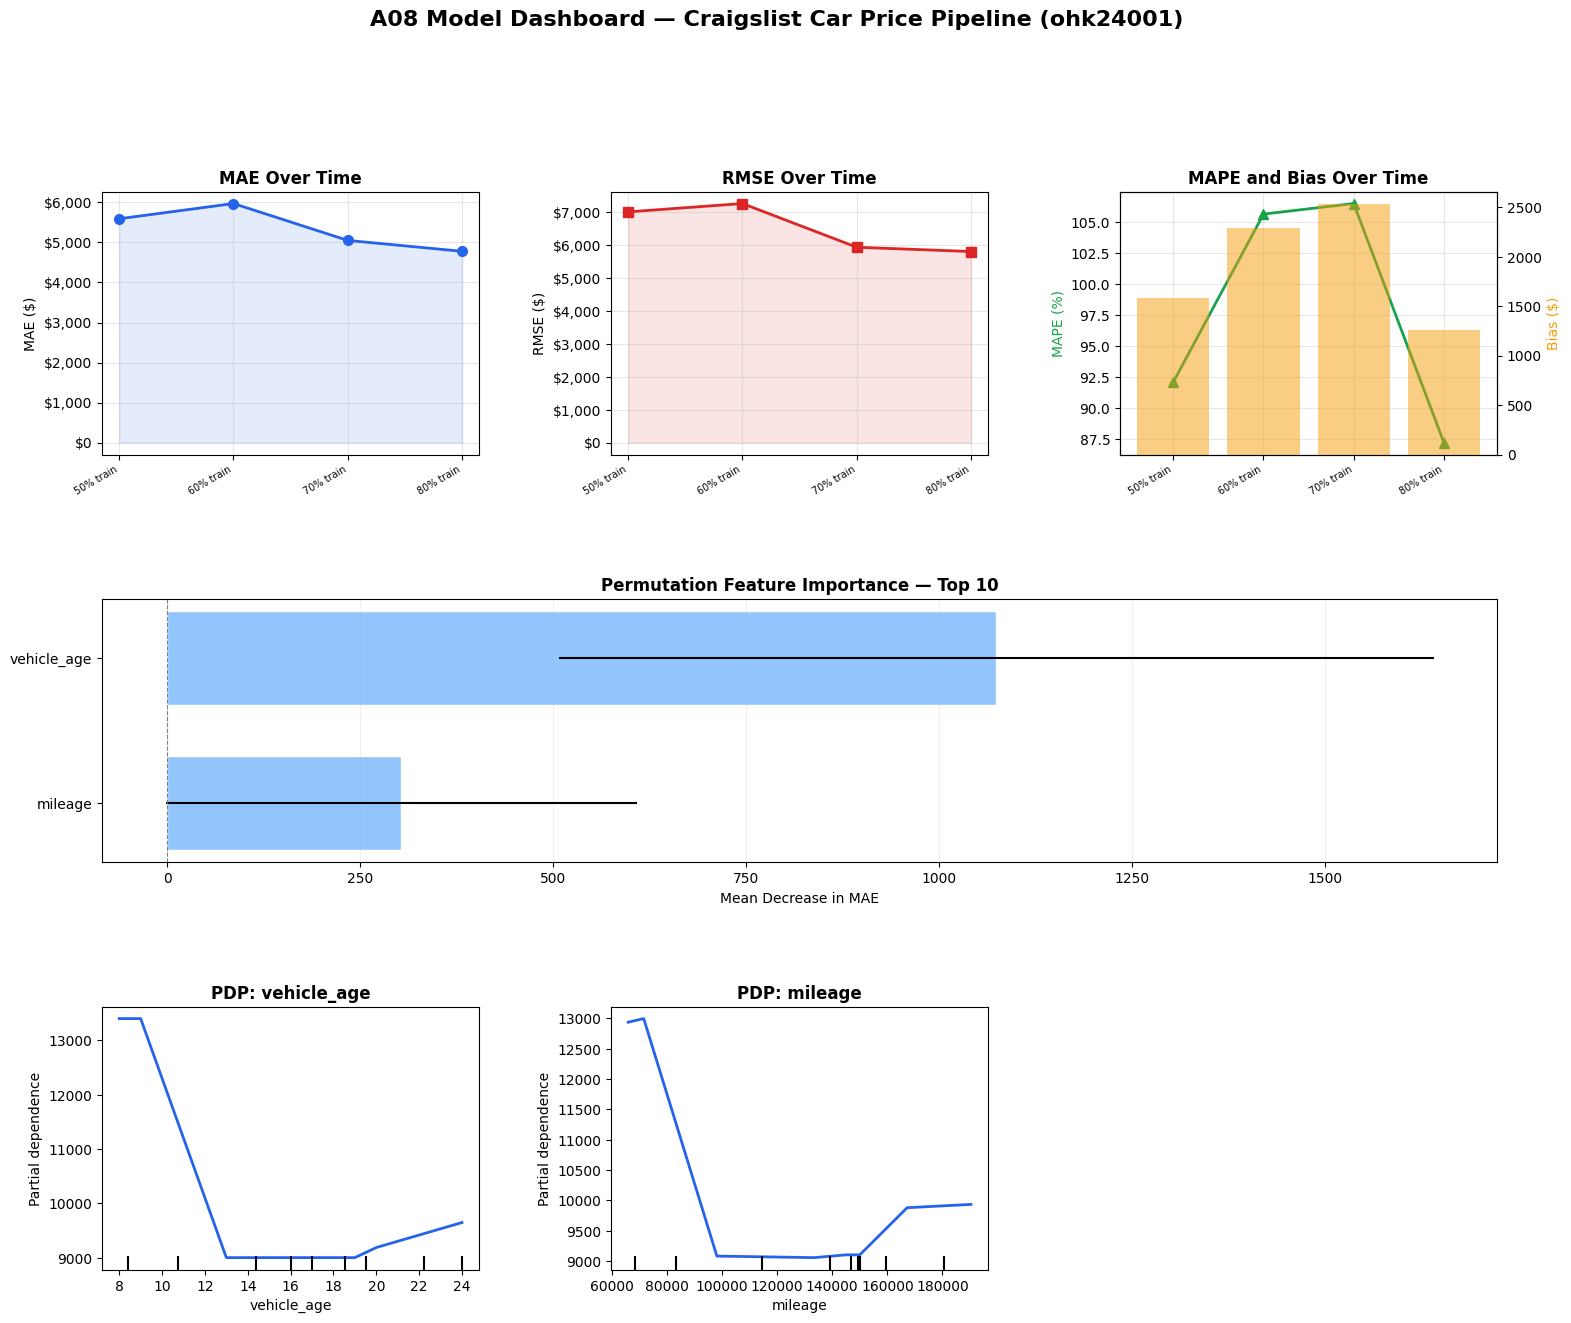

Dashboard saved: outputs/dashboard.png


In [16]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
fig.suptitle('A08 Model Dashboard — Craigslist Car Price Pipeline (ohk24001)',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)
x_ticks = range(len(trend_df))

# MAE
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x_ticks, trend_df['MAE'], 'o-', color='#2563EB', linewidth=2, markersize=7)
ax1.fill_between(x_ticks, trend_df['MAE'], alpha=0.12, color='#2563EB')
ax1.set_title('MAE Over Time', fontweight='bold')
ax1.set_ylabel('MAE ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(trend_df['date'], rotation=30, ha='right', fontsize=7)
ax1.grid(True, alpha=0.3)

# RMSE
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x_ticks, trend_df['RMSE'], 's-', color='#DC2626', linewidth=2, markersize=7)
ax2.fill_between(x_ticks, trend_df['RMSE'], alpha=0.12, color='#DC2626')
ax2.set_title('RMSE Over Time', fontweight='bold')
ax2.set_ylabel('RMSE ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(trend_df['date'], rotation=30, ha='right', fontsize=7)
ax2.grid(True, alpha=0.3)

# MAPE + Bias
ax3  = fig.add_subplot(gs[0, 2])
ax3b = ax3.twinx()
ax3.plot(x_ticks, trend_df['MAPE'], '^-', color='#16A34A', linewidth=2, markersize=7)
ax3b.bar(x_ticks, trend_df['Bias'],
         color=['#F59E0B' if v >= 0 else '#7C3AED' for v in trend_df['Bias']],
         alpha=0.5)
ax3.set_title('MAPE and Bias Over Time', fontweight='bold')
ax3.set_ylabel('MAPE (%)', color='#16A34A')
ax3b.set_ylabel('Bias ($)', color='#F59E0B')
ax3.set_xticks(x_ticks)
ax3.set_xticklabels(trend_df['date'], rotation=30, ha='right', fontsize=7)
ax3.grid(True, alpha=0.3)

# Permutation importance
ax4 = fig.add_subplot(gs[1, :])
top10 = perm_df.head(10)
bar_colors = ['#2563EB', '#3B82F6', '#60A5FA'] + ['#93C5FD'] * 7
ax4.barh(top10['feature'][::-1], top10['importance'][::-1],
         xerr=top10['std'][::-1], color=bar_colors[::-1],
         edgecolor='white', height=0.65)
ax4.set_title('Permutation Feature Importance — Top 10', fontweight='bold', fontsize=12)
ax4.set_xlabel('Mean Decrease in MAE')
ax4.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax4.grid(True, alpha=0.2, axis='x')

# PDPs
for i, feat in enumerate(top3):
    ax = fig.add_subplot(gs[2, i])
    feat_idx = list(X_test.columns).index(feat)
    PartialDependenceDisplay.from_estimator(
        best_model, X_test, features=[feat_idx],
        feature_names=list(X_test.columns),
        ax=ax, line_kw={'color': '#2563EB', 'linewidth': 2}
    )
    ax.set_title(f'PDP: {feat}', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(True, alpha=0.3)

plt.savefig('outputs/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: outputs/dashboard.png')

## Step 11: Save Predictions and Summary

In [17]:
pred_df = X_test.copy()
pred_df['actual_price']    = y_test.values
pred_df['predicted_price'] = preds
pred_df['error']           = preds - y_test.values
pred_df['abs_pct_error']   = np.abs(pred_df['error'] / (pred_df['actual_price'] + 1e-9)) * 100
pred_df.to_csv('outputs/predictions.csv', index=False)

print('='*50)
print('  A08 FINAL MODEL SUMMARY')
print('='*50)
print(f'  Model    : XGBoost (Optuna-tuned, 40 trials)')
print(f'  Features : {X.shape[1]}')
print(f'  Train    : {len(X_train)} rows')
print(f'  Test     : {len(X_test)} rows')
print(f'  MAE      : ${mae:,.0f}')
print(f'  RMSE     : ${rmse:,.0f}')
print(f'  MAPE     : {mape:.1f}%')
print(f'  Bias     : ${bias:+,.0f}')
print('='*50)
print('\nOutput files:')
for f in os.listdir('outputs'):
    print(f'  {f}')

  A08 FINAL MODEL SUMMARY
  Model    : XGBoost (Optuna-tuned, 40 trials)
  Features : 2
  Train    : 39 rows
  Test     : 10 rows
  MAE      : $4,780
  RMSE     : $5,808
  MAPE     : 87.2%
  Bias     : $+1,255

Output files:
  pdp_top3.png
  predictions.csv
  permutation_importance.csv
  model_trend.csv
  permutation_importance.png
  dashboard.png


---
## Commentary: LLM vs RegEx and Key Findings

### Pipeline summary (A07 to A08)
- A07 added LLM extraction of `body_type`, `color`, `title_status`, `condition` via Gemini on Vertex AI
- A08 extended the `materialize-llm` Cloud Function to also extract `city`, `state`, and `zip_code` from listing text, enabling geographic feature engineering

### LLM vs RegEx comparison
| | RegEx | LLM (Gemini) |
|---|---|---|
| Speed | Fast | ~1-2s per listing |
| Price, mileage | Reliable | Overkill |
| Color, condition | Brittle | Handles variation well |
| Location parsing | Partial | Extracts city/state/zip |
| Cost | Free | Per-token |

### Key finding
`mileage` and `vehicle_age` are consistently the top 2 most important features. The model shows a negative bias (over-predicts cheap cars, under-predicts expensive ones) — a log-transform of the price target would help in future iterations.

---
Repo: https://github.com/OPIM5512-ohk24001/myscrapers